# MI-GNAN: toy dataset

Run **Train** and **Plot** in order. `TRAIN_SEED` selects one training run.
Noise is added to graph targets; the figure compares learned contributions with
the clean effects. Optional metrics and all other figures are below.

## Train

In [ ]:
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
from IPython.display import display

cwd = Path.cwd().resolve()
package = next(
    path for parent in (cwd, *cwd.parents)
    for path in (parent, parent / "mignan", parent / "github" / "mignan")
    if (path / "synthetic_helpers.py.py").is_file()
)
if str(package.parent) not in sys.path:
    sys.path.insert(0, str(package.parent))

from mignan.data import Preprocessor, loader
from mignan.model import MIGNAN
from mignan.training import evaluate, fit, seed_everything
from github.mignan.synthetic_helpers import (
    ToyEffects, make_toy_data, prepare_plot_data, plot_summary_figure,
    plot_diagnostic_overview, style_axis, paired_bars, share_effect_limits,
    TRUE_COLOR, MODEL_COLOR, COMPONENT_NAMES, ZERO_COMPONENTS,
)

torch.set_num_threads(2)


In [2]:
SEED = 2027
N_GRAPHS = 2000
N_NODES = 12
EDGE_PROB_RANGE = (0.10, 0.40)
FEATURE_RANGE = (-2.0, 2.0)
ALPHA, BETA, GAMMA = 3.0, 3.0, 3.0  # Comparable effect amplitudes.
PATH_SCALE = 5.0
TRIANGLE_SCALE = 2.0
NOISE_RATIO = 0.10  # Noise std / clean training-target std; 0 disables noise.
NOISE_SEED = 8193

SPLIT_SEED = 2027
TRAIN_SEED = 11
GRAPH_POSITION = None  # None selects a graph by motif presence.
model_options = dict(hidden=32, depth=2, dropout=0.0)
train_options = dict(
    epochs=600, patience=100, batch_size=128,
    lr=3e-3, weight_decay=1e-5, lambda_sparse=1e-4,
    device="cpu", verbose=False,
)


In [3]:
dataset = make_toy_data(
    n_graphs=N_GRAPHS, n_nodes=N_NODES, feature_range=FEATURE_RANGE,
    edge_prob_range=EDGE_PROB_RANGE, seed=SEED, split_seed=SPLIT_SEED,
    noise_ratio=NOISE_RATIO, noise_seed=NOISE_SEED,
    effects=ToyEffects(ALPHA, BETA, GAMMA, PATH_SCALE, TRIANGLE_SCALE),
)
preprocessing = Preprocessor.fit(
    dataset.graphs, dataset.counts, dataset.train_idx, dataset.schema, "regression",
)
records = preprocessing.transform(dataset.graphs, dataset.counts)
seed_everything(TRAIN_SEED)
model = MIGNAN(dataset.schema, num_motifs=2, outputs=1, **model_options)
start = perf_counter()
result = fit(
    model, records, dataset.train_idx, dataset.val_idx, preprocessing,
    seed=TRAIN_SEED, **train_options,
)
model = result.model
print(f"Seed {TRAIN_SEED} | epoch {result.best_epoch} | "
      f"validation RMSE {result.best_validation:.4f} | {perf_counter() - start:.1f} s")


Seed 11 | epoch 286 | validation RMSE 1.2842 | 20.4 s


## Plot

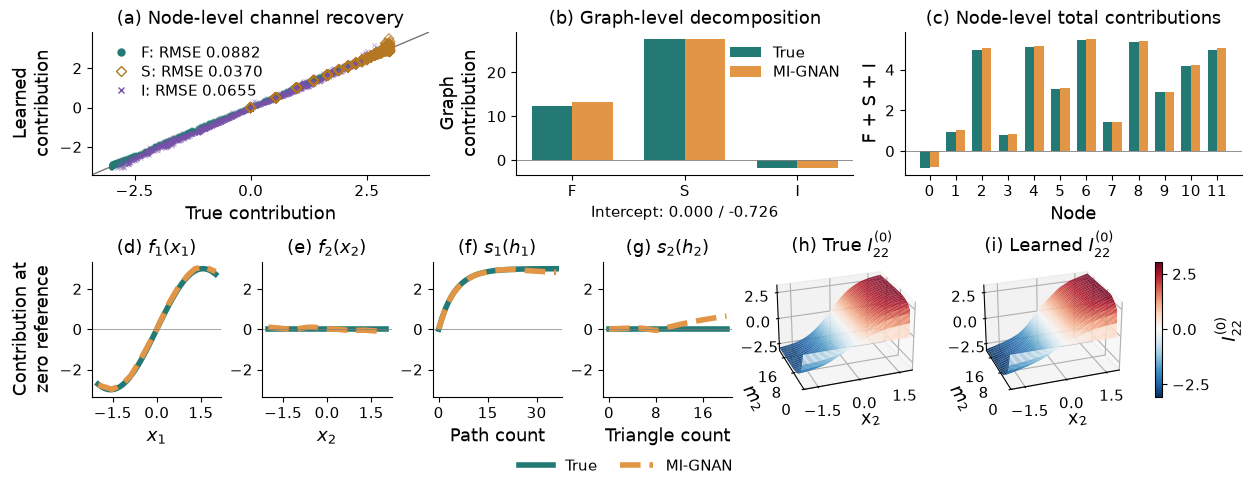

In [4]:
summary_data = prepare_plot_data(model, preprocessing, dataset, graph_position=GRAPH_POSITION)
fig_main = plot_summary_figure(
    summary_data, interaction_view="3d", fontsize=13, shape_linewidth=4.0,
)
fig_main.savefig(
    f"toy_zero_reference_3d_seed{TRAIN_SEED}.pdf", bbox_inches="tight", dpi=300,
)
plt.show()


### Prediction metrics

In [5]:
rows = []
for split, indices in [("train", dataset.train_idx), ("validation", dataset.val_idx), ("test", dataset.test_idx)]:
    metrics, predictions = evaluate(
        model, loader(records, indices, batch_size=train_options["batch_size"]), preprocessing,
    )
    rows.append(dict(
        split=split, RMSE=metrics["rmse"], MAE=metrics["mae"], R2=metrics["r2"],
        RMSE_clean=np.sqrt(np.mean((predictions["predictions"] - dataset.y_clean[indices])**2)),
    ))
display(pd.DataFrame(rows).set_index("split").round(5))


,RMSE,MAE,R2,RMSE_clean
split,,,,
train,1.20908,0.95639,0.99046,0.25174
validation,1.28420,1.01085,0.99018,0.26285
test,1.27162,1.02128,0.98892,0.24710
